
# **BISMILLAH FINAL PROJECT**

### **Step 1 : Collecting Dataset**

Dataset Collected
1. Energy Consumption Sector Industry, Household, and Commercial. Source : HANDBOOK OF ENERGY & ECONOMIC STATISTICS OF INDONESIA (2016,2019,& 2024)
2. Emisson CO2. Source : www.ourworldindata.org
3. Emission Greenhouse. Source : www.ourworldindata.org
4. Change Surface Temperature. Source : International Monetary Fund (IMF) climate data

### **Step 2 : Preprocessing Dataset**

### 1. Panggil Library yang akan digunakan

In [1]:
import pandas as pd
import numpy as np
from IPython.display import Markdown, display
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose
import io
from matplotlib.ticker import FuncFormatter
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import math
from scipy.stats import boxcox, yeojohnson
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import pyinform
import itertools
import time
from math import sqrt

### 2. Data Energi Sektor Industri

In [2]:
industri= pd.read_csv("D:/PENS22/TUGAS AKHIR/Data/KonsumsiEnergiIndustri.csv",delimiter=';')
industri

,Year,Biomass,Coal,Briquette,Gas,Kerosene,Gasoil CN 48,MDF,BioGasoil,Fuel Oil,Total Fuel,Other Petroleum Product,LPG,Electricity,Total
0,2000,58981,36060,85,66826,4219,37171,8008,n.a,25581,74979,13435,1073,20850,292289
1,2001,55186,37021,78,81861,4160,39458,7735,n.a,26680,78033,25712,972,21819,300683
2,2002,52303,38698,83,80508,3955,38282,7311,n.a,25596,75690,22688,1093,22578,299643
3,2003,50167,68264,77,89912,3980,37398,6358,n.a,20756,68493,23533,808,22337,323626
4,2004,46917,55344,80,85076,4012,42986,5862,n.a,25194,74178,37716,1101,24719,325670
5,2005,43920,65744,94,86277,3851,39929,4843,n.a,15617,64239,29614,1131,26021,317040
6,2006,46676,89043,94,82845,3394,35027,2627,n.a,16154,57203,41126,1453,26736,345178
7,2007,42108,121904,89,79723,3352,33787,1422,n.a,13856,52418,39873,1242,28077,365434
8,2008,44235,94035,155,90227,2676,30095,865,n.a,27482,61118,n.a,1127,29405,320302
9,2009,44521,82587,220,89101,1619,32238,706,n.a,24888,59451,n.a,588,28323,304791


In [3]:
industri.insert(loc=1, column='Sector', value='Industri')
industri

,Year,Sector,Biomass,Coal,Briquette,Gas,Kerosene,Gasoil CN 48,MDF,BioGasoil,Fuel Oil,Total Fuel,Other Petroleum Product,LPG,Electricity,Total
0,2000,Industri,58981,36060,85,66826,4219,37171,8008,n.a,25581,74979,13435,1073,20850,292289
1,2001,Industri,55186,37021,78,81861,4160,39458,7735,n.a,26680,78033,25712,972,21819,300683
2,2002,Industri,52303,38698,83,80508,3955,38282,7311,n.a,25596,75690,22688,1093,22578,299643
3,2003,Industri,50167,68264,77,89912,3980,37398,6358,n.a,20756,68493,23533,808,22337,323626
4,2004,Industri,46917,55344,80,85076,4012,42986,5862,n.a,25194,74178,37716,1101,24719,325670
5,2005,Industri,43920,65744,94,86277,3851,39929,4843,n.a,15617,64239,29614,1131,26021,317040
6,2006,Industri,46676,89043,94,82845,3394,35027,2627,n.a,16154,57203,41126,1453,26736,345178
7,2007,Industri,42108,121904,89,79723,3352,33787,1422,n.a,13856,52418,39873,1242,28077,365434
8,2008,Industri,44235,94035,155,90227,2676,30095,865,n.a,27482,61118,n.a,1127,29405,320302
9,2009,Industri,44521,82587,220,89101,1619,32238,706,n.a,24888,59451,n.a,588,28323,304791


In [4]:
# Missing Values
industri = industri.replace('n.a', np.nan).fillna(0)
industri

,Year,Sector,Biomass,Coal,Briquette,Gas,Kerosene,Gasoil CN 48,MDF,BioGasoil,Fuel Oil,Total Fuel,Other Petroleum Product,LPG,Electricity,Total
0,2000,Industri,58981,36060,85,66826,4219,37171,8008,0,25581,74979,13435,1073,20850,292289
1,2001,Industri,55186,37021,78,81861,4160,39458,7735,0,26680,78033,25712,972,21819,300683
2,2002,Industri,52303,38698,83,80508,3955,38282,7311,0,25596,75690,22688,1093,22578,299643
3,2003,Industri,50167,68264,77,89912,3980,37398,6358,0,20756,68493,23533,808,22337,323626
4,2004,Industri,46917,55344,80,85076,4012,42986,5862,0,25194,74178,37716,1101,24719,325670
5,2005,Industri,43920,65744,94,86277,3851,39929,4843,0,15617,64239,29614,1131,26021,317040
6,2006,Industri,46676,89043,94,82845,3394,35027,2627,0,16154,57203,41126,1453,26736,345178
7,2007,Industri,42108,121904,89,79723,3352,33787,1422,0,13856,52418,39873,1242,28077,365434
8,2008,Industri,44235,94035,155,90227,2676,30095,865,0,27482,61118,0,1127,29405,320302
9,2009,Industri,44521,82587,220,89101,1619,32238,706,0,24888,59451,0,588,28323,304791


### 3. Data Energi Sektor Rumah Tangga

In [5]:
rumahtangga= pd.read_csv("D:/PENS22/TUGAS AKHIR/Data/KonsumsiEnergiRumahTangga.csv",delimiter=';')
rumahtangga

,Year,Biomass,Gas,Kerosene,LPG,Electricity,Total
0,2000,208610,81,63216,5932,18735,296573
1,2001,212323,87,62329,6170,20437,301347
2,2002,216465,96,59261,6373,20838,303033
3,2003,220377,99,59640,7013,21917,309046
4,2004,223425,124,60112,6798,23655,314115
5,2005,224707,124,57696,5998,25246,313772
6,2006,228186,128,50862,6719,26821,312716
7,2007,231616,132,50229,8345,29010,319333
8,2008,68422,131,40096,13487,30763,152899
9,2009,63082,130,24255,22767,33682,143915


In [6]:
rumahtangga.insert(loc=1, column='Sector', value='Rumah Tangga')
rumahtangga

,Year,Sector,Biomass,Gas,Kerosene,LPG,Electricity,Total
0,2000,Rumah Tangga,208610,81,63216,5932,18735,296573
1,2001,Rumah Tangga,212323,87,62329,6170,20437,301347
2,2002,Rumah Tangga,216465,96,59261,6373,20838,303033
3,2003,Rumah Tangga,220377,99,59640,7013,21917,309046
4,2004,Rumah Tangga,223425,124,60112,6798,23655,314115
5,2005,Rumah Tangga,224707,124,57696,5998,25246,313772
6,2006,Rumah Tangga,228186,128,50862,6719,26821,312716
7,2007,Rumah Tangga,231616,132,50229,8345,29010,319333
8,2008,Rumah Tangga,68422,131,40096,13487,30763,152899
9,2009,Rumah Tangga,63082,130,24255,22767,33682,143915


In [7]:
#Mengelola Missing Values
rumahtangga = rumahtangga.replace('n.a', np.nan).fillna(0)
rumahtangga

,Year,Sector,Biomass,Gas,Kerosene,LPG,Electricity,Total
0,2000,Rumah Tangga,208610,81,63216,5932,18735,296573
1,2001,Rumah Tangga,212323,87,62329,6170,20437,301347
2,2002,Rumah Tangga,216465,96,59261,6373,20838,303033
3,2003,Rumah Tangga,220377,99,59640,7013,21917,309046
4,2004,Rumah Tangga,223425,124,60112,6798,23655,314115
5,2005,Rumah Tangga,224707,124,57696,5998,25246,313772
6,2006,Rumah Tangga,228186,128,50862,6719,26821,312716
7,2007,Rumah Tangga,231616,132,50229,8345,29010,319333
8,2008,Rumah Tangga,68422,131,40096,13487,30763,152899
9,2009,Rumah Tangga,63082,130,24255,22767,33682,143915


### 4. Data Energi Sektor Komersial

In [8]:
komersial= pd.read_csv("D:/PENS22/TUGAS AKHIR/Data/KonsumsiEnergiKomersial.csv",delimiter=';')
komersial

,Year,Biomass,Gas,Kerosene,Gasoil CN 48,MDF,Total Fuel,LPG,Electricity,Total
0,2000,1452,134,3491,5352,43,8886,1257,8943,20670
1,2001,1444,147,3442,5682,42,9165,1138,9555,21450
2,2002,1437,164,3272,5591,39,8903,1279,9570,21752
3,2003,1430,158,3293,5385,34,8712,946,11151,22397
4,2004,1423,174,3319,6190,31,9540,1288,12986,25412
5,2005,1416,190,3186,5749,26,8961,1324,14344,26235
6,2006,1409,206,2809,5044,14,7866,1241,15473,26195
7,2007,1402,274,2774,4865,8,7646,1337,17237,27896
8,2008,1395,357,2214,4333,5,6552,1044,18871,28219
9,2009,1388,330,1394,4642,4,5985,1029,20482,29559


In [9]:
komersial.insert(loc=1, column='Sector', value='Komersial')
komersial

,Year,Sector,Biomass,Gas,Kerosene,Gasoil CN 48,MDF,Total Fuel,LPG,Electricity,Total
0,2000,Komersial,1452,134,3491,5352,43,8886,1257,8943,20670
1,2001,Komersial,1444,147,3442,5682,42,9165,1138,9555,21450
2,2002,Komersial,1437,164,3272,5591,39,8903,1279,9570,21752
3,2003,Komersial,1430,158,3293,5385,34,8712,946,11151,22397
4,2004,Komersial,1423,174,3319,6190,31,9540,1288,12986,25412
5,2005,Komersial,1416,190,3186,5749,26,8961,1324,14344,26235
6,2006,Komersial,1409,206,2809,5044,14,7866,1241,15473,26195
7,2007,Komersial,1402,274,2774,4865,8,7646,1337,17237,27896
8,2008,Komersial,1395,357,2214,4333,5,6552,1044,18871,28219
9,2009,Komersial,1388,330,1394,4642,4,5985,1029,20482,29559


In [10]:
#Mengelola Missing Values
komersial = komersial.replace('n.a', np.nan).fillna(0)
komersial

,Year,Sector,Biomass,Gas,Kerosene,Gasoil CN 48,MDF,Total Fuel,LPG,Electricity,Total
0,2000,Komersial,1452,134,3491,5352,43,8886,1257,8943,20670
1,2001,Komersial,1444,147,3442,5682,42,9165,1138,9555,21450
2,2002,Komersial,1437,164,3272,5591,39,8903,1279,9570,21752
3,2003,Komersial,1430,158,3293,5385,34,8712,946,11151,22397
4,2004,Komersial,1423,174,3319,6190,31,9540,1288,12986,25412
5,2005,Komersial,1416,190,3186,5749,26,8961,1324,14344,26235
6,2006,Komersial,1409,206,2809,5044,14,7866,1241,15473,26195
7,2007,Komersial,1402,274,2774,4865,8,7646,1337,17237,27896
8,2008,Komersial,1395,357,2214,4333,5,6552,1044,18871,28219
9,2009,Komersial,1388,330,1394,4642,4,5985,1029,20482,29559


### 5. Data Emsisi CO2 Indonesia

In [11]:
karbon= pd.read_csv("D:/PENS22/TUGAS AKHIR/Data/Data CO2 Indonesia.csv",delimiter=',')
karbon

,Entity,Year,Annual CO₂ emissions
0,Indonesia,2000,281330370
1,Indonesia,2001,317027200
2,Indonesia,2002,308485920
3,Indonesia,2003,339357470
4,Indonesia,2004,343021500
5,Indonesia,2005,347617020
6,Indonesia,2006,346633440
7,Indonesia,2007,387858050
8,Indonesia,2008,365718300
9,Indonesia,2009,398942050


In [12]:
karbon = karbon.rename(columns={"Annual CO₂ emissions": "Emission_CO₂"})
karbon

,Entity,Year,Emission_CO₂
0,Indonesia,2000,281330370
1,Indonesia,2001,317027200
2,Indonesia,2002,308485920
3,Indonesia,2003,339357470
4,Indonesia,2004,343021500
5,Indonesia,2005,347617020
6,Indonesia,2006,346633440
7,Indonesia,2007,387858050
8,Indonesia,2008,365718300
9,Indonesia,2009,398942050


### 6. Data Emisi GRK Indonesia

In [13]:
grk = pd.read_csv("D:/PENS22/TUGAS AKHIR/Data/greenhouse-gas-emissions Indonesia.csv",delimiter=',')
grk

,Entity,Year,Annual greenhouse gas emissions in CO₂ equivalents
0,Indonesia,2000,1386973000
1,Indonesia,2001,1373519600
2,Indonesia,2002,1588074400
3,Indonesia,2003,1289581000
4,Indonesia,2004,1384788200
5,Indonesia,2005,1316794500
6,Indonesia,2006,1893063000
7,Indonesia,2007,1285662800
8,Indonesia,2008,1322040700
9,Indonesia,2009,1705499000


In [14]:
grk = grk.rename(columns={"Annual greenhouse gas emissions in CO₂ equivalents": "Emission_GRK"})
grk

,Entity,Year,Emission_GRK
0,Indonesia,2000,1386973000
1,Indonesia,2001,1373519600
2,Indonesia,2002,1588074400
3,Indonesia,2003,1289581000
4,Indonesia,2004,1384788200
5,Indonesia,2005,1316794500
6,Indonesia,2006,1893063000
7,Indonesia,2007,1285662800
8,Indonesia,2008,1322040700
9,Indonesia,2009,1705499000


### 7. Data Perubahan Permukaan Suhu Indonesia

In [15]:
suhu= pd.read_csv("D:/PENS22/TUGAS AKHIR/Data/Perubahan Permukaan Suhu Tahunan Indonesia.csv",delimiter=';')
suhu = suhu.replace('–', '-', regex=True)
suhu

,ObjectId,Country,ISO2,ISO3,Indicator,Unit,Source,CTS Code,CTS Name,CTS Full Descriptor,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,97,Indonesia,ID,IDN,Temperature change with respect to a baseline ...,Degree Celsius,Food and Agriculture Organization of the Unite...,ECCS,Surface Temperature Change,"Environment, Climate Change, Climate and Weath...",...,0.771,1.41,0.957,0.879,1.045,1.233,1.02,0.969,1.101,1.472


In [16]:
# Cek semua kolom yang berbentuk tahun
year_cols = [col for col in suhu.columns if col.isdigit()]
suhu[year_cols] = suhu[year_cols].apply(pd.to_numeric, errors='coerce')

# Lakukan melt
suhu_melted = pd.melt(
    suhu,
    id_vars=['Country', 'Unit'],
    value_vars=year_cols,
    var_name='Year',
    value_name='Temperature'
)
suhu_melted

,Country,Unit,Year,Temperature
0,Indonesia,Degree Celsius,1961,-0.049
1,Indonesia,Degree Celsius,1962,0.016
2,Indonesia,Degree Celsius,1963,-0.105
3,Indonesia,Degree Celsius,1964,0.002
4,Indonesia,Degree Celsius,1965,-0.203
...,...,...,...,...
59,Indonesia,Degree Celsius,2020,1.233
60,Indonesia,Degree Celsius,2021,1.020
61,Indonesia,Degree Celsius,2022,0.969
62,Indonesia,Degree Celsius,2023,1.101


In [17]:
suhu_melted['Year'] = suhu_melted['Year'].astype(int)
suhu_filtered = suhu_melted[suhu_melted['Year'] >= 2000]
temp = suhu_filtered[['Country', 'Year', 'Temperature', 'Unit']].reset_index(drop=True)
temp

,Country,Year,Temperature,Unit
0,Indonesia,2000,0.234,Degree Celsius
1,Indonesia,2001,0.470,Degree Celsius
2,Indonesia,2002,0.594,Degree Celsius
3,Indonesia,2003,0.621,Degree Celsius
4,Indonesia,2004,0.574,Degree Celsius
5,Indonesia,2005,0.709,Degree Celsius
6,Indonesia,2006,0.388,Degree Celsius
7,Indonesia,2007,0.430,Degree Celsius
8,Indonesia,2008,0.226,Degree Celsius
9,Indonesia,2009,0.532,Degree Celsius


### **Step 3 : Exploration Data Anlysis**

In [18]:
#1 Statistic Descriptive Energy Consumption
display(Markdown("**1. Statistik Deskriptif Konsumsi Energi**"))

**1. Statistik Deskriptif Konsumsi Energi**

In [19]:
#1.1 Statistic Descriptive Energy Consumption by Industrial Sector
display(Markdown("**1.1 Statistik Deskriptif Konsumsi Energi Sektor Industri**"))
industri.describe().astype(int)

**1.1 Statistik Deskriptif Konsumsi Energi Sektor Industri**

,Year,Biomass,Coal,Briquette,Gas,Kerosene,Gasoil CN 48,MDF,Fuel Oil,Total Fuel,LPG,Electricity,Total
count,25,25,25,25,25,25,25,25,25,25,25,25,25
mean,2012,29627,112472,85,93541,1600,27291,2061,16689,50983,943,40086,338318
std,7,23007,85778,56,12691,1686,16012,2754,6527,18129,216,16643,90012
min,2000,45,36060,0,66826,170,1099,233,7669,22578,588,20850,237807
25%,2006,637,58800,50,85729,203,18517,314,11586,32288,788,26736,292289
50%,2012,43317,87820,85,91342,468,32238,544,14751,54108,972,36888,317040
75%,2018,46676,123022,121,105492,3394,38282,2627,21820,64239,1093,54638,363535
max,2024,58981,342672,220,119192,4219,49515,8008,27482,78033,1453,72811,586240


In [20]:
#1.2 Statistic Descriptive Energy Consumption by Household Sector
display(Markdown("**1.2 Statistik Deskriptif Konsumsi Energi Sektor Rumah Tangga**"))
rumahtangga.describe().astype(int)

**1.2 Statistik Deskriptif Konsumsi Energi Sektor Rumah Tangga**

,Year,Biomass,Gas,Kerosene,LPG,Electricity,Total
count,25,25,25,25,25,25,25
mean,2012,96312,268,23984,37417,45455,203475
std,7,88582,289,25271,26214,20082,74150
min,2000,15043,81,2551,5932,18735,143915
25%,2006,26622,122,3038,7013,26821,149436
50%,2012,55139,132,7015,41123,44217,158357
75%,2018,212323,239,50862,61819,60927,301347
max,2024,231616,1128,63216,76690,83450,319333


In [21]:
#1.3 Statistic Descriptive Energy Consumption by Commercial Sector
display(Markdown("**1.3 Statistik Deskriptif Konsumsi Energi Sektor Komersial**"))
komersial.describe().astype(int)

**1.3 Statistik Deskriptif Konsumsi Energi Sektor Komersial**

,Year,Biomass,Gas,Kerosene,Gasoil CN 48,MDF,Total Fuel,LPG,Electricity,Total
count,25,25,25,25,25,25,25,25,25,25
mean,2012,1367,681,1338,4035,11,5812,1401,25879,35293
std,7,50,466,1388,2219,14,2578,317,11712,10088
min,2000,1287,134,141,191,1,2236,946,8943,20670
25%,2006,1326,206,168,2666,2,2836,1139,15473,26235
50%,2012,1360,701,587,4840,3,5985,1324,26567,37655
75%,2018,1409,1204,2809,5591,14,7866,1628,36516,43175
max,2024,1452,1447,3491,7130,43,9540,2015,49709,58360


In [22]:
#2. Statistic Descriptive Data Climate Change by Emission CO2
display(Markdown("**2.1 Statistik Deskriptif Emisi CO2**"))
karbon.describe().astype(int)

**2.1 Statistik Deskriptif Emisi CO2**

,Year,Emission_CO₂
count,24,24
mean,2011,477401475
std,7,135565306
min,2000,281330370
25%,2005,347371125
50%,2011,488472525
75%,2017,566233500
max,2023,737072640


In [23]:
#2. Statistic Descriptive Data Climate Change by GreenHouse Effect
display(Markdown("**2.2 Statistik Deskriptif Emisi Gas Rumah Kaca**"))
grk.describe().round(0).astype('int64')

**2.2 Statistik Deskriptif Emisi Gas Rumah Kaca**

,Year,Emission_GRK
count,24,24
mean,2012,1688352658
std,7,299295752
min,2000,1285662800
25%,2006,1386426800
50%,2012,1709937800
75%,2017,1824891925
max,2023,2499634000


In [24]:
#2. Statistic Descriptive Data Climate Change by Change Surface Temperature
display(Markdown("**2.3 Statistik Deskriptif Perubahan Permukaan Suhu Tahunan**"))
temp.describe().astype(str)

**2.3 Statistik Deskriptif Perubahan Permukaan Suhu Tahunan**

,Year,Temperature
count,25.0,25.0
mean,2012.0,0.745
std,7.359800721939872,0.3447719052745839
min,2000.0,0.226
25%,2006.0,0.47
50%,2012.0,0.742
75%,2018.0,0.969
max,2024.0,1.472


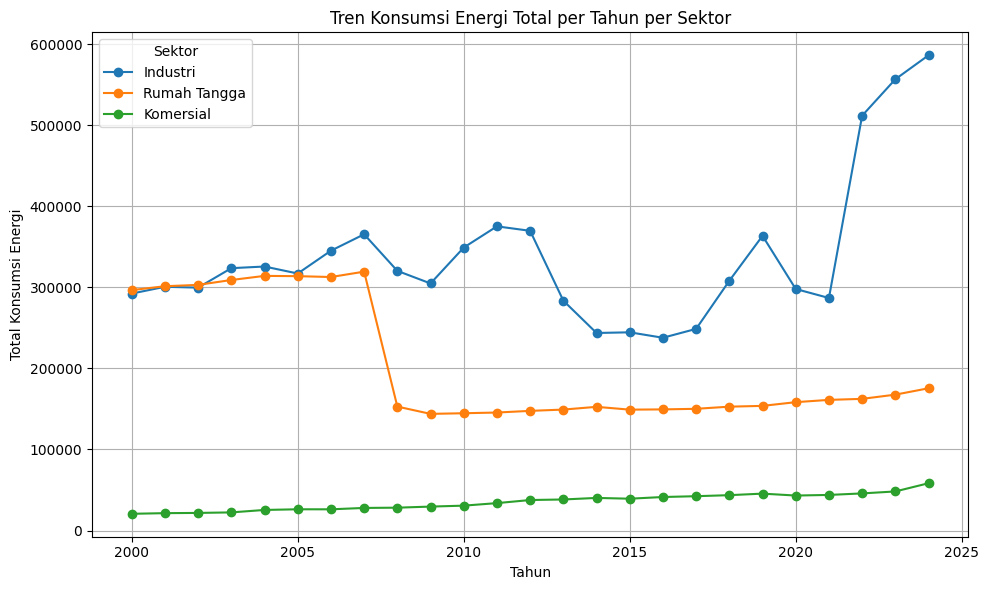

In [25]:
plt.figure(figsize=(10,6))

plt.plot(industri["Year"], industri["Total"], marker="o", label="Industri")
plt.plot(rumahtangga["Year"], rumahtangga["Total"], marker="o", label="Rumah Tangga")
plt.plot(komersial["Year"], komersial["Total"], marker="o", label="Komersial")

plt.title("Tren Konsumsi Energi Total per Tahun per Sektor")
plt.xlabel("Tahun")
plt.ylabel("Total Konsumsi Energi")
plt.legend(title="Sektor")
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
import matplotlib.pyplot as plt
import math

def plot_dataset(df, title="Tren Konsumsi Energi", ncols=3):

    # ambil kolom numerik, kecuali Year & Total
    numeric_cols = df.select_dtypes(include="number").columns
    numeric_cols = [col for col in numeric_cols if col not in ["Year", "Total"]]

    n = len(numeric_cols)
    nrows = math.ceil(n / ncols)  # baris otomatis

    fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), squeeze=False)
    fig.suptitle(title, fontsize=14, y=1.02)

    for i, col in enumerate(numeric_cols):
        r, c = divmod(i, ncols)
        ax = axes[r, c]
        ax.plot(df["Year"], df[col], marker="o", label=col)
        ax.set_title(col, fontsize=10)
        ax.set_xlabel("Tahun")
        ax.set_ylabel("Konsumsi Energi")
        ax.grid(True)
        ax.legend(fontsize=8)

    # hapus subplot kosong kalau ada
    for j in range(i+1, nrows*ncols):
        r, c = divmod(j, ncols)
        fig.delaxes(axes[r, c])

    plt.tight_layout()
    plt.show()

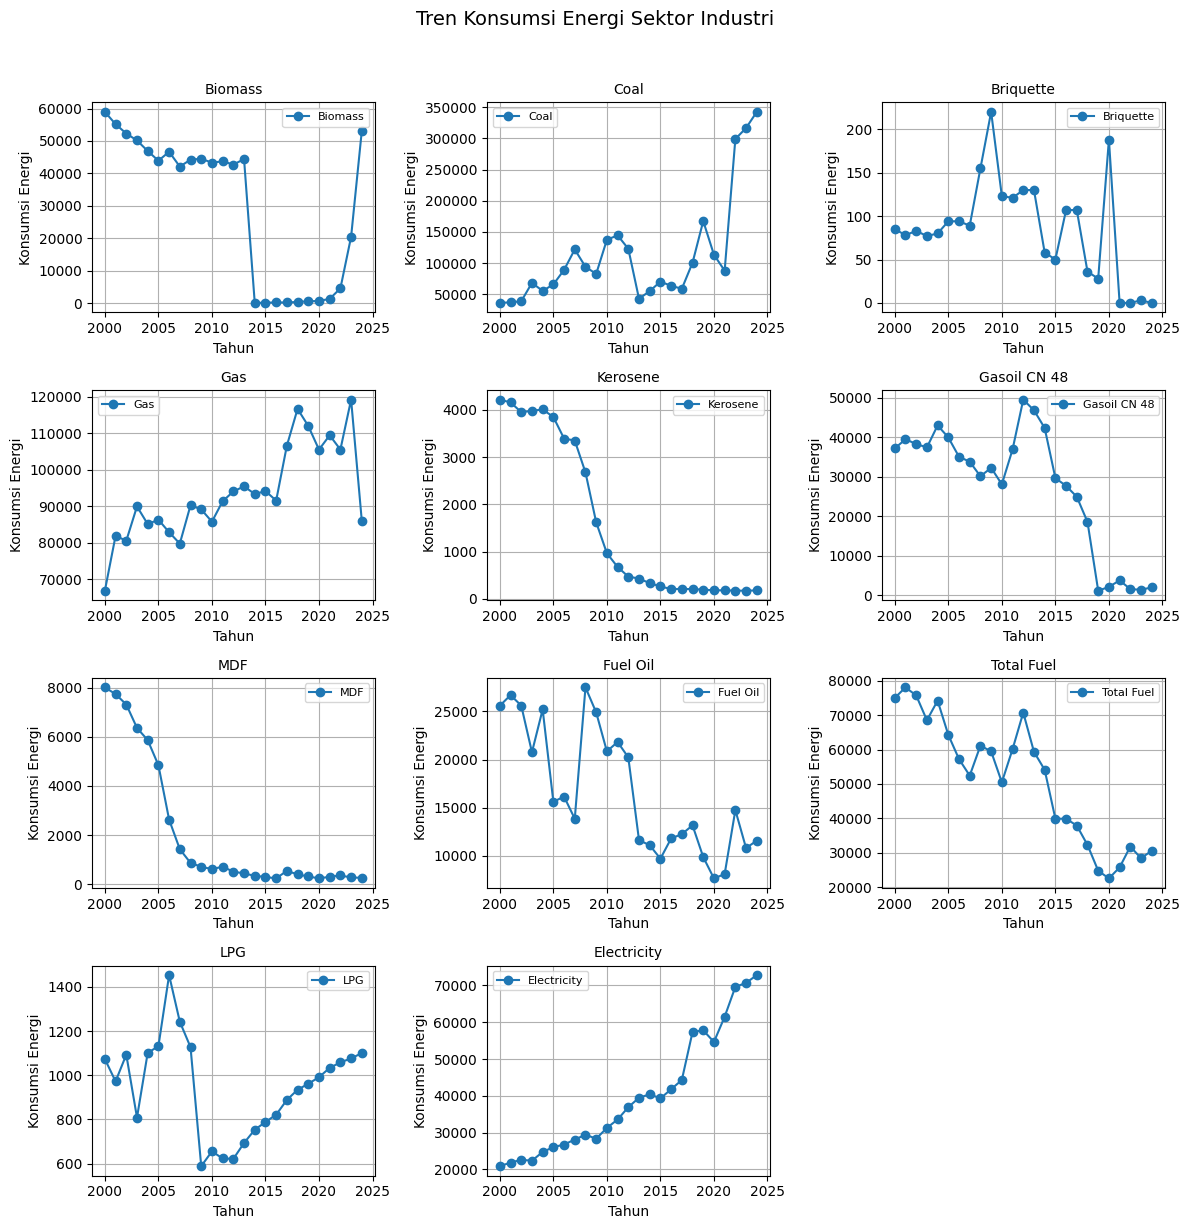

In [27]:
plot_dataset(industri, "Tren Konsumsi Energi Sektor Industri")

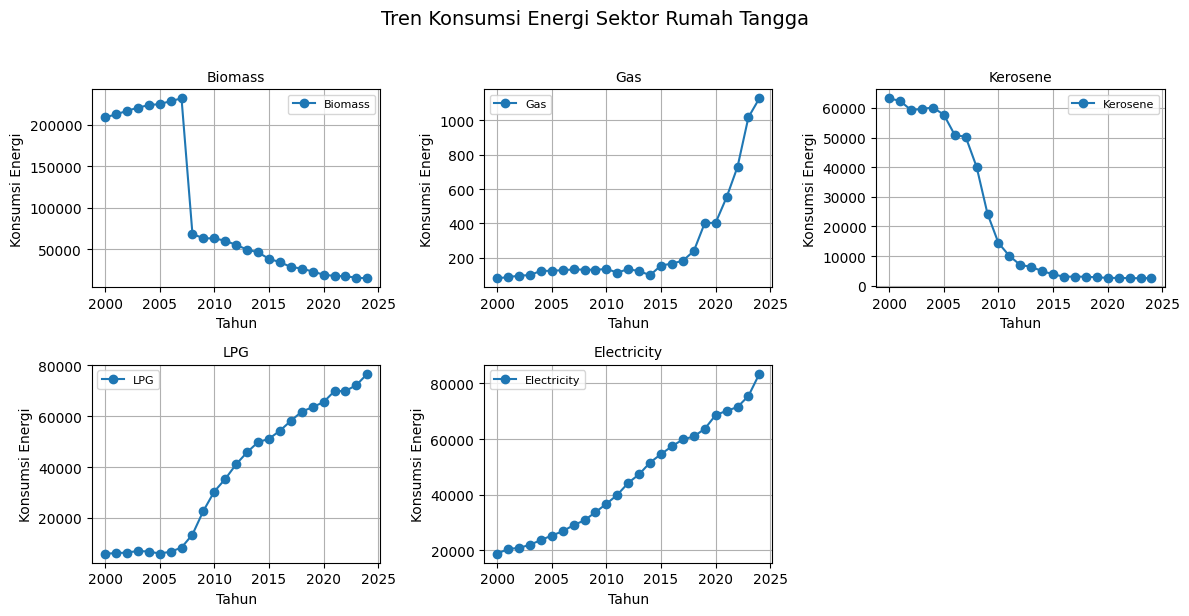

In [28]:
plot_dataset(rumahtangga, "Tren Konsumsi Energi Sektor Rumah Tangga")

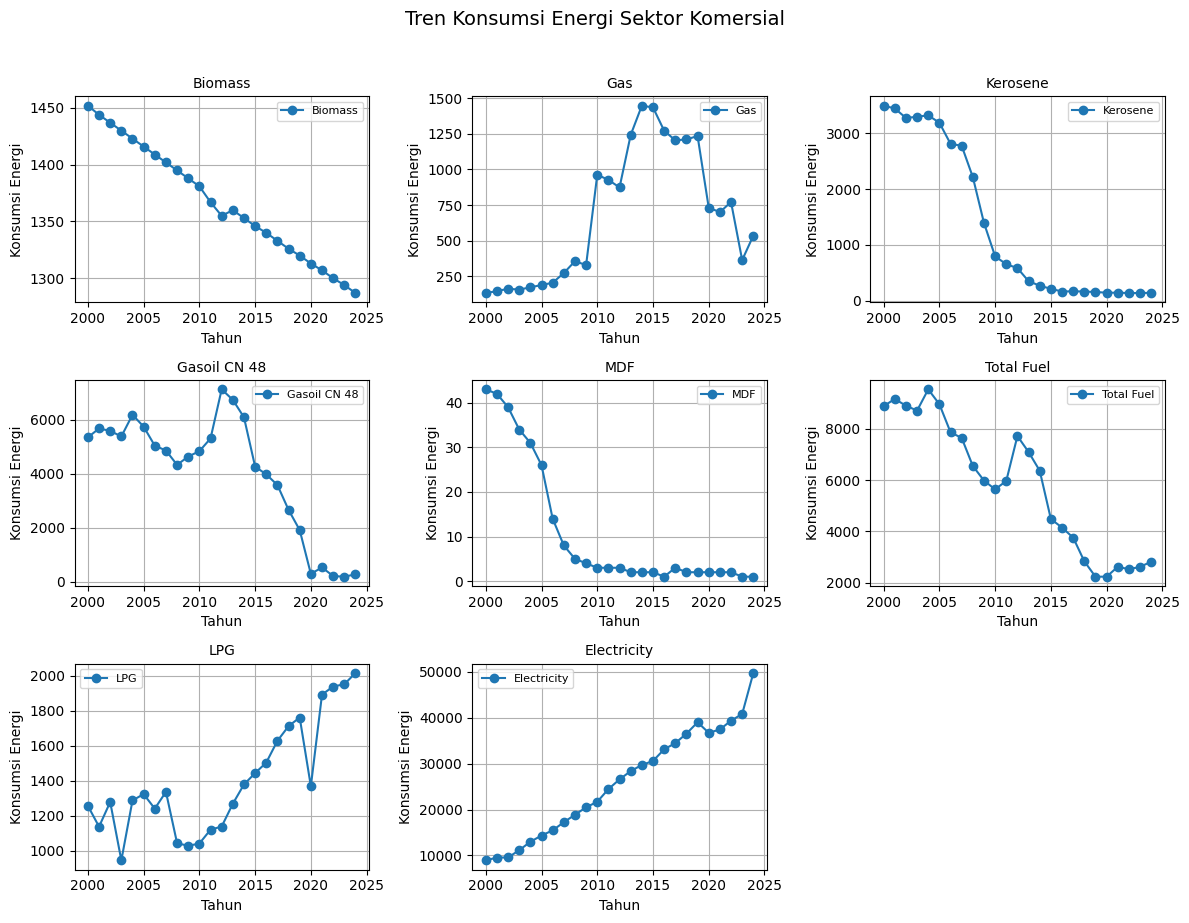

In [29]:
plot_dataset(komersial, "Tren Konsumsi Energi Sektor Komersial")

**3.2 Analisis Pola Emisi CO2**

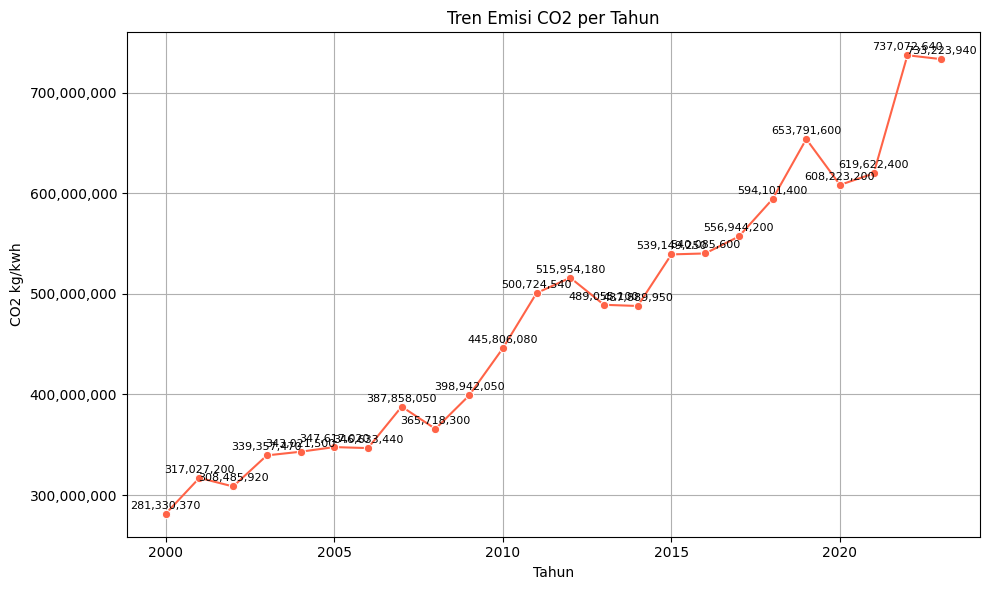

In [30]:
#3.2 Analisis Pola Perubahan Iklim Tahunan
display(Markdown("**3.2 Analisis Pola Emisi CO2**"))

plt.figure(figsize=(10,6))
sns.lineplot(data=karbon, x='Year', y='Emission_CO₂', marker='o',color='tomato')

for x, y in zip(karbon['Year'], karbon['Emission_CO₂']):
    if pd.notna(y):
        plt.text(x, y + 5_000_000, f'{int(y):,}', ha='center', fontsize=8)

formatter = FuncFormatter(lambda x, pos: f'{int(x):,}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Tren Emisi CO2 per Tahun")
plt.xlabel("Tahun")
plt.ylabel("CO2 kg/kwh")
plt.grid(True)
plt.tight_layout()
plt.show()

**3.3 Analisis Pola Emisi Gas Rumah Kaca**

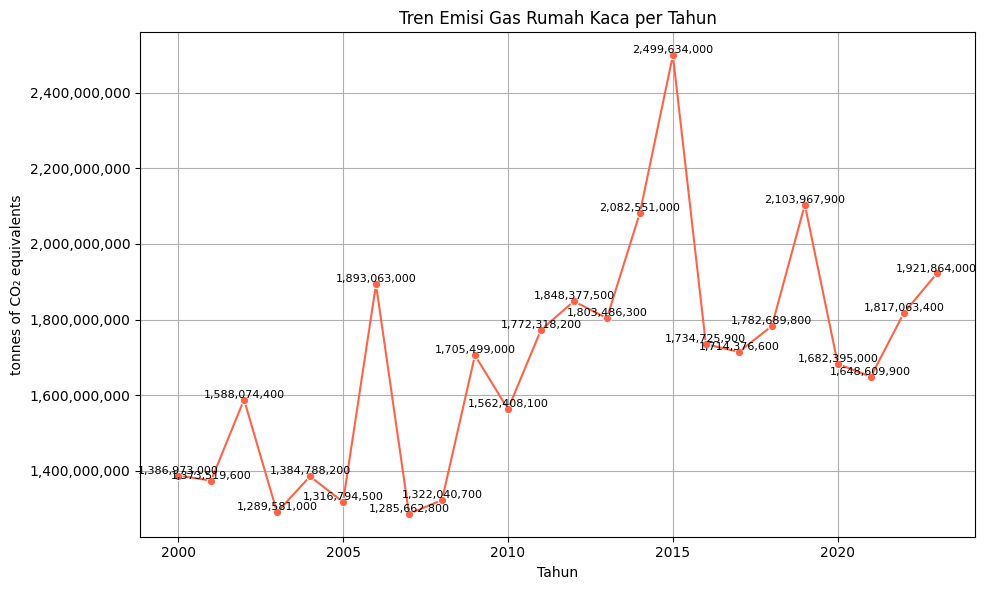

In [31]:
#3.2 Analisis Pola Perubahan Iklim Tahunan
display(Markdown("**3.3 Analisis Pola Emisi Gas Rumah Kaca**"))

plt.figure(figsize=(10,6))
sns.lineplot(data=grk, x='Year', y='Emission_GRK', marker='o',color='tomato')

for x, y in zip(grk['Year'], grk['Emission_GRK']):
    if pd.notna(y):
        plt.text(x, y + 5_000_000, f'{int(y):,}', ha='center', fontsize=8)

formatter = FuncFormatter(lambda x, pos: f'{int(x):,}')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Tren Emisi Gas Rumah Kaca per Tahun")
plt.xlabel("Tahun")
plt.ylabel("tonnes of CO₂ equivalents")
plt.grid(True)
plt.tight_layout()
plt.show()

**3.4 Analisis Pola Perubahan Suhu Permukaan**

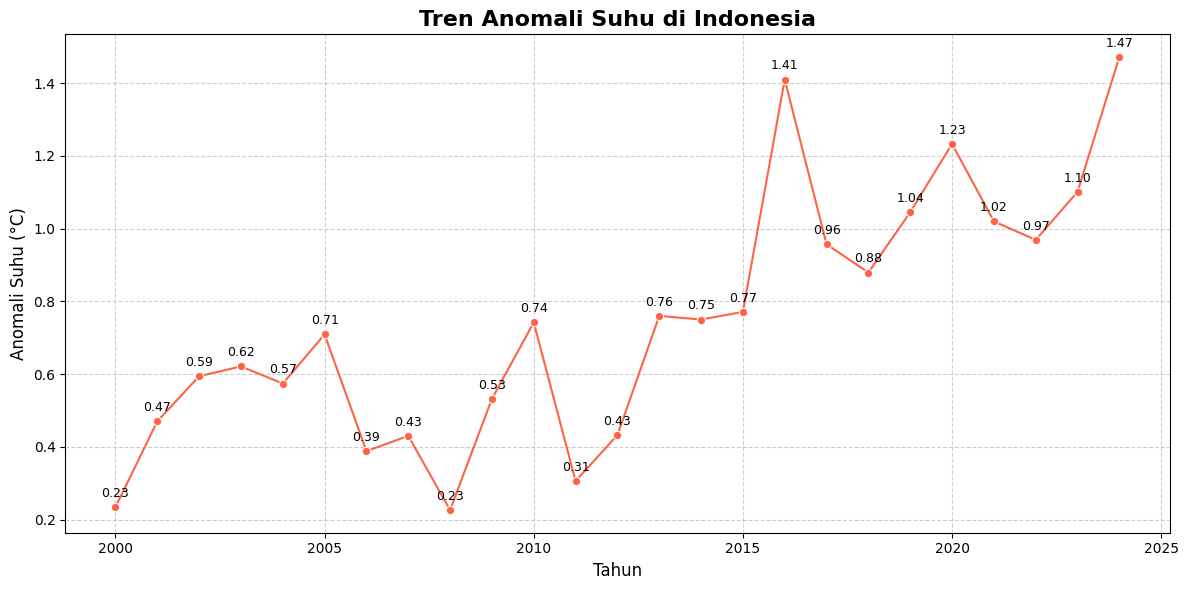

In [32]:
#3.2 Analisis Pola Perubahan Iklim Tahunan
display(Markdown("**3.4 Analisis Pola Perubahan Suhu Permukaan**"))

temp['Year'] = temp['Year'].astype(int)
temp['Temperature'] = temp['Temperature'].astype(float)

plt.figure(figsize=(12,6))
sns.lineplot(data=temp, x='Year', y='Temperature', marker='o', color='tomato')

for x, y in zip(temp['Year'], temp['Temperature']):
    plt.text(x, y+0.02, f"{y:.2f}", ha='center', va='bottom', fontsize=9, color='black')

plt.title('Tren Anomali Suhu di Indonesia', fontsize=16, weight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Anomali Suhu (°C)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [33]:
#3. Correlation beetween each dataset
display(Markdown("**3. Korelasi antar dataset**"))

**3. Korelasi antar dataset**

**3.2 Korelasi Data Energi Industri dengan Perubahan Iklim**

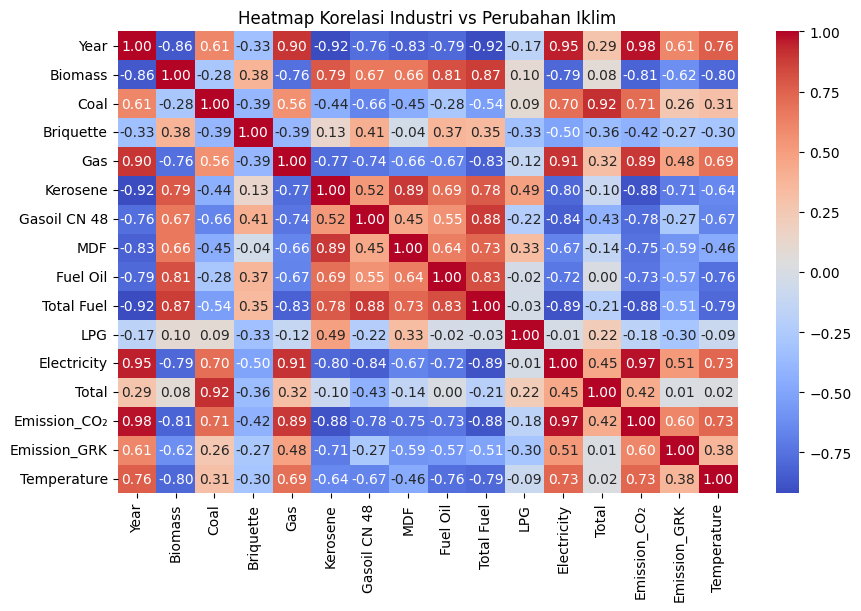

In [34]:
#3. Correlation beetween each dataset
display(Markdown("**3.2 Korelasi Data Energi Industri dengan Perubahan Iklim**"))

# Menggabungkan data industri dan karbon berdasarkan Year
df_ind_iklim = industri.merge(karbon, on="Year", suffixes=("_Industri", "_Karbon"))
df_ind_iklim = df_ind_iklim.merge(grk, on="Year", suffixes=("", "_GRK"))
df_ind_iklim = df_ind_iklim.merge(temp, on="Year", suffixes=("", "_Temp"))

# Ambil kolom numerik
df_num = df_ind_iklim.select_dtypes(include=["number"])

# Hitung korelasi
corr_matrix = df_num.corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Industri vs Perubahan Iklim")
plt.show()

 Hasil Analisis Korelasi
- Dapat dilihat dalam analisis korelasi antara data energi industri dengan perubahan iklim. Penggunaan energi listrik, batubara, dan gas memiliki hubungan positif dengan variable2 perubahan iklim yakni, CO2, Emisi gas rumah kaca, dan Perubahan Suhu permukaan

**3.3 Korelasi Data Energi Rumah Tangga dengan Perubahan Iklim**

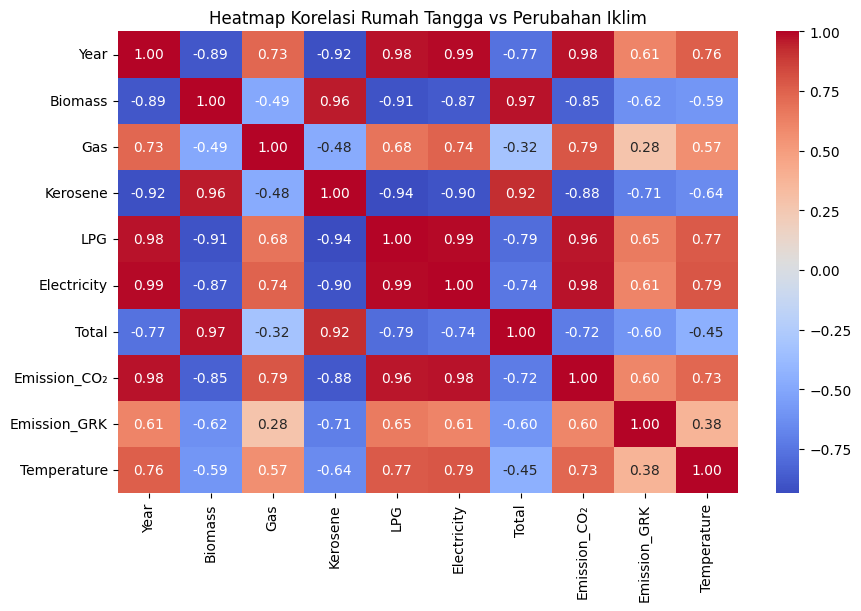

In [35]:
#3. Correlation beetween each dataset
display(Markdown("**3.3 Korelasi Data Energi Rumah Tangga dengan Perubahan Iklim**"))

# Menggabungkan data Rumah Tangga dengan Perubahan Iklim berdasarkan Year
df_rt_iklim = rumahtangga.merge(karbon, on="Year", suffixes=("", ""))
df_rt_iklim = df_rt_iklim.merge(grk, on="Year", suffixes=("", "_GRK"))
df_rt_iklim = df_rt_iklim.merge(temp, on="Year", suffixes=("", "_Temp"))

# Ambil kolom numerik
df_num = df_rt_iklim.select_dtypes(include=["number"])

# Hitung korelasi
corr_matrix = df_num.corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Rumah Tangga vs Perubahan Iklim")
plt.show()

 Hasil Analisis Korelasi
- Dapat dilihat dalam analisis korelasi antara data energi rumah tangga dengan perubahan iklim. Penggunaan energi listrik, LPG, dan gas memiliki hubungan positif dengan variable2 perubahan iklim yakni, CO2, Emisi gas rumah kaca, dan Perubahan Suhu permukaan

**3.4 Korelasi Data Energi Komersial dengan Perubahan Iklim**

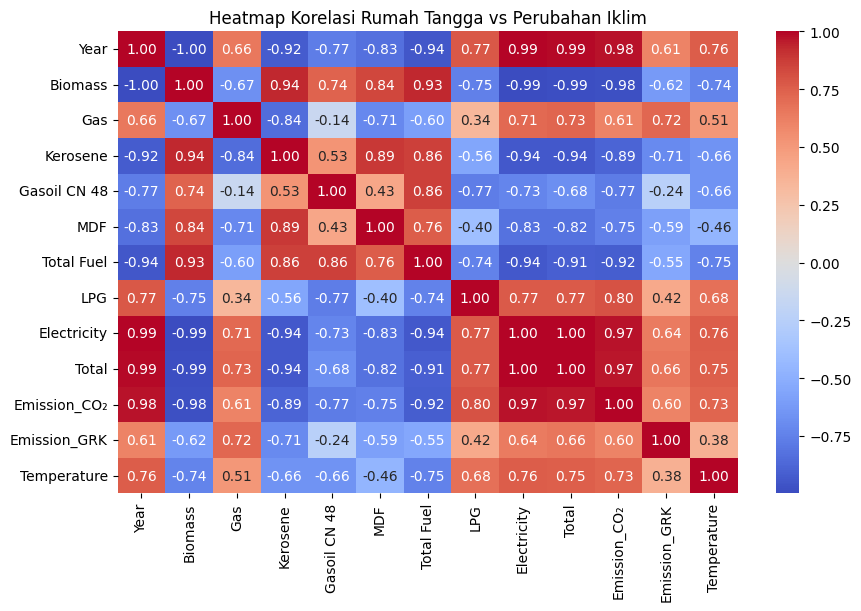

In [36]:
#3. Correlation beetween each dataset
display(Markdown("**3.4 Korelasi Data Energi Komersial dengan Perubahan Iklim**"))

# Menggabungkan data Komersial dengan Perubahan Iklim berdasarkan Year
df_kom_iklim = komersial.merge(karbon, on="Year", suffixes=("", ""))
df_kom_iklim = df_kom_iklim.merge(grk, on="Year", suffixes=("", "_GRK"))
df_kom_iklim = df_kom_iklim.merge(temp, on="Year", suffixes=("", "_Temp"))

# Ambil kolom numerik
df_num = df_kom_iklim.select_dtypes(include=["number"])

# Hitung korelasi
corr_matrix = df_num.corr()

# Plot heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Korelasi Rumah Tangga vs Perubahan Iklim")
plt.show()

 Hasil Analisis Korelasi
- Dapat dilihat dalam analisis korelasi antara data energi komersial dengan perubahan iklim. Penggunaan energi listrik, LPG, dan gas memiliki hubungan positif dengan variable2 perubahan iklim yakni, CO2, Emisi gas rumah kaca, dan Perubahan Suhu permukaan

### **Step 5 : Modelling type 2**
**Predictive modelling with Seq2Seq and Causality Test with Transfer Entropy**

In [37]:
df_ind = industri.add_prefix("Ind_")
df_rt = rumahtangga.add_prefix("RT_")
df_kom = komersial.add_prefix("Kom_")

df_energy= pd.concat([df_ind, df_rt, df_kom], axis=1)
data_energy = df_energy.dropna()

data_energy = data_energy.rename(columns={"Ind_Year": "Year"})
data_energy = data_energy.drop(columns=["RT_Year", "Kom_Year", "Ind_Sector", "RT_Sector", "Kom_Sector"])

data_energy = data_energy.astype(int)
data_energy = data_energy[data_energy['Year'] != 2024]
data_energy

,Year,Ind_Biomass,Ind_Coal,Ind_Briquette,Ind_Gas,Ind_Kerosene,Ind_Gasoil CN 48,Ind_MDF,Ind_BioGasoil,Ind_Fuel Oil,...,RT_Total,Kom_Biomass,Kom_Gas,Kom_Kerosene,Kom_Gasoil CN 48,Kom_MDF,Kom_Total Fuel,Kom_LPG,Kom_Electricity,Kom_Total
0,2000,58981,36060,85,66826,4219,37171,8008,0,25581,...,296573,1452,134,3491,5352,43,8886,1257,8943,20670
1,2001,55186,37021,78,81861,4160,39458,7735,0,26680,...,301347,1444,147,3442,5682,42,9165,1138,9555,21450
2,2002,52303,38698,83,80508,3955,38282,7311,0,25596,...,303033,1437,164,3272,5591,39,8903,1279,9570,21752
3,2003,50167,68264,77,89912,3980,37398,6358,0,20756,...,309046,1430,158,3293,5385,34,8712,946,11151,22397
4,2004,46917,55344,80,85076,4012,42986,5862,0,25194,...,314115,1423,174,3319,6190,31,9540,1288,12986,25412
5,2005,43920,65744,94,86277,3851,39929,4843,0,15617,...,313772,1416,190,3186,5749,26,8961,1324,14344,26235
6,2006,46676,89043,94,82845,3394,35027,2627,0,16154,...,312716,1409,206,2809,5044,14,7866,1241,15473,26195
7,2007,42108,121904,89,79723,3352,33787,1422,0,13856,...,319333,1402,274,2774,4865,8,7646,1337,17237,27896
8,2008,44235,94035,155,90227,2676,30095,865,0,27482,...,152899,1395,357,2214,4333,5,6552,1044,18871,28219
9,2009,44521,82587,220,89101,1619,32238,706,0,24888,...,143915,1388,330,1394,4642,4,5985,1029,20482,29559


In [38]:
# Pastikan Year jadi datetime index
data_energy["Year"] = pd.to_datetime(data_energy["Year"], format="%Y")

# Jadikan indeks
data_energy = data_energy.set_index("Year")
data_energy

,Ind_Biomass,Ind_Coal,Ind_Briquette,Ind_Gas,Ind_Kerosene,Ind_Gasoil CN 48,Ind_MDF,Ind_BioGasoil,Ind_Fuel Oil,Ind_Total Fuel,...,RT_Total,Kom_Biomass,Kom_Gas,Kom_Kerosene,Kom_Gasoil CN 48,Kom_MDF,Kom_Total Fuel,Kom_LPG,Kom_Electricity,Kom_Total
Year,,,,,,,,,,,,,,,,,,,,,
2000-01-01,58981,36060,85,66826,4219,37171,8008,0,25581,74979,...,296573,1452,134,3491,5352,43,8886,1257,8943,20670
2001-01-01,55186,37021,78,81861,4160,39458,7735,0,26680,78033,...,301347,1444,147,3442,5682,42,9165,1138,9555,21450
2002-01-01,52303,38698,83,80508,3955,38282,7311,0,25596,75690,...,303033,1437,164,3272,5591,39,8903,1279,9570,21752
2003-01-01,50167,68264,77,89912,3980,37398,6358,0,20756,68493,...,309046,1430,158,3293,5385,34,8712,946,11151,22397
2004-01-01,46917,55344,80,85076,4012,42986,5862,0,25194,74178,...,314115,1423,174,3319,6190,31,9540,1288,12986,25412
2005-01-01,43920,65744,94,86277,3851,39929,4843,0,15617,64239,...,313772,1416,190,3186,5749,26,8961,1324,14344,26235
2006-01-01,46676,89043,94,82845,3394,35027,2627,0,16154,57203,...,312716,1409,206,2809,5044,14,7866,1241,15473,26195
2007-01-01,42108,121904,89,79723,3352,33787,1422,0,13856,52418,...,319333,1402,274,2774,4865,8,7646,1337,17237,27896
2008-01-01,44235,94035,155,90227,2676,30095,865,0,27482,61118,...,152899,1395,357,2214,4333,5,6552,1044,18871,28219


In [39]:
from pycaret.time_series import *
import pandas as pd

result_rows = []   # menyimpan hasil akhir dalam bentuk list of dict

for col in data_energy.columns:
    print(f"\n============================")
    print(f" Training Forecasting untuk: {col}")
    print(f"============================")

    df = data_energy[[col]]

    setup(
        data=df,
        target=col,
        fh=3,
        fold=3,
        session_id=123,
        verbose=False
    )

    best = compare_models()
    final_model = finalize_model(best)
    forecast = predict_model(final_model, fh=12)

    # Ambil metrik terakhir dari compare_models
    metrics = pull().iloc[-1]

    # Simpan ke list
    result_rows.append({
        "Variable": col,
        "Best_Model": best.__class__.__name__,   # nama model
        **metrics.to_dict()                      # semua metrik
    })

# Buat DataFrame hasil rekap
df_result = pd.DataFrame(result_rows)

print("\n============================")
print(" Rekap Model Terbaik Tiap Variabel")
print("============================")
print(df_result)


 Training Forecasting untuk: Ind_Biomass


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
naive,Naive Forecaster,2.1312,3.1032,5186.4444,8566.1649,108.2946,0.8960,-7.3751,1.6133
auto_arima,Auto ARIMA,2.2288,3.2221,5420.7104,8889.6922,112.4099,0.8971,-7.4146,0.1867
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,2.8625,2.9958,8897.0692,11403.0197,110.1256,1.5772,-33632.2330,0.0600
theta,Theta Forecaster,3.0039,3.3211,9596.1935,12707.5274,124.1542,1.5386,-28828.2432,0.0300
knn_cds_dt,K Neighbors w/ Cond. Deseasonalize & Detrending,3.7973,3.4404,13794.0108,16258.7315,146.4266,1.4251,-205806.1361,0.0933
rf_cds_dt,Random Forest w/ Cond. Deseasonalize & Detrending,3.8139,3.4626,14032.3381,16660.2511,147.6321,1.5619,-209739.0252,0.1500
br_cds_dt,Bayesian Ridge w/ Cond. Deseasonalize & Detrending,3.8200,3.3631,13964.3695,16127.6058,145.5551,1.2805,-230736.9584,0.0667
ada_cds_dt,AdaBoost w/ Cond. Deseasonalize & Detrending,3.9827,3.6255,14491.3313,17133.5965,153.9423,1.5648,-214976.3543,0.0867
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,3.9948,3.4793,14951.9270,17453.8189,154.6396,1.4341,-300296.8670,0.2833
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,3.9948,3.4793,14951.9270,17453.8188,154.6396,1.4341,-300296.8604,0.3300



 Training Forecasting untuk: Ind_Coal


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
croston,Croston,1.6248,3.7315,33357.6082,36544.2761,0.3690,0.3795,-3.0791,0.0133
grand_means,Grand Means Forecaster,1.6317,3.7421,33616.6796,36663.7186,0.3928,0.3829,-4.5429,0.0200
arima,ARIMA,1.8747,4.1824,38131.5842,43331.2035,0.5150,0.4210,-2.8530,0.0400
ets,ETS,2.0837,4.5502,42207.8010,49110.8489,0.6188,0.4418,-4.4651,0.0300
ada_cds_dt,AdaBoost w/ Cond. Deseasonalize & Detrending,2.2128,4.4959,44089.5093,52670.2985,0.7036,0.4049,-3.6972,0.0900
gbr_cds_dt,Gradient Boosting w/ Cond. Deseasonalize & Detrending,2.2200,4.7675,44687.0579,52299.8571,0.6330,0.4520,-3.5587,0.0800
auto_arima,Auto ARIMA,2.2788,4.7058,45953.9357,51144.3028,0.6558,0.4709,-3.6990,0.1133
dt_cds_dt,Decision Tree w/ Cond. Deseasonalize & Detrending,2.2876,4.8412,45995.3683,53363.2778,0.6690,0.4610,-3.7068,0.0567
exp_smooth,Exponential Smoothing,2.4325,5.0600,48981.3028,55039.6546,0.6925,0.5014,-3.9930,0.0233
naive,Naive Forecaster,2.4457,5.1094,49440.5556,54551.4479,0.6820,0.5236,-4.4551,0.0400



 Training Forecasting untuk: Ind_Briquette


...


 Training Forecasting untuk: Kom_Electricity


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
auto_arima,Auto ARIMA,0.6468,0.6299,948.4300,1011.2996,0.0287,0.0288,0.1064,0.1500
exp_smooth,Exponential Smoothing,0.6468,0.6299,948.4621,1011.3341,0.0287,0.0288,0.1063,0.0267
rf_cds_dt,Random Forest w/ Cond. Deseasonalize & Detrending,0.8720,0.8232,1263.6284,1310.9815,0.0401,0.0409,-0.4840,0.1600
theta,Theta Forecaster,0.8988,0.9046,1309.2607,1444.0881,0.0405,0.0414,-0.3126,0.0267
knn_cds_dt,K Neighbors w/ Cond. Deseasonalize & Detrending,0.9094,0.8840,1319.7636,1409.6960,0.0416,0.0424,-0.5896,0.0967
ets,ETS,0.9207,0.8745,1334.5726,1393.0328,0.0424,0.0432,-0.6007,0.0367
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,0.9556,0.9075,1389.3039,1447.4479,0.0434,0.0443,-0.5389,0.0733
lasso_cds_dt,Lasso w/ Cond. Deseasonalize & Detrending,0.9806,0.9315,1424.8144,1485.2298,0.0446,0.0456,-0.6246,0.0600
llar_cds_dt,Lasso Least Angular Regressor w/ Cond. Deseasonalize & Detrending,0.9806,0.9315,1424.8144,1485.2298,0.0446,0.0456,-0.6246,0.0600
omp_cds_dt,Orthogonal Matching Pursuit w/ Cond. Deseasonalize & Detrending,0.9806,0.9315,1424.8134,1485.2288,0.0446,0.0456,-0.6246,0.0667



 Training Forecasting untuk: Kom_Total


,Model,MASE,RMSSE,MAE,RMSE,MAPE,SMAPE,R2,TT (Sec)
theta,Theta Forecaster,1.4612,1.2350,1870.0701,2039.1365,0.0466,0.0476,-3.0160,0.0267
auto_arima,Auto ARIMA,1.4713,1.2642,1923.6608,2126.4207,0.0476,0.0476,-2.6444,0.1433
lightgbm_cds_dt,Light Gradient Boosting w/ Cond. Deseasonalize & Detrending,1.5397,1.3331,1924.7021,2160.1413,0.0484,0.0502,-5.1988,0.0767
polytrend,Polynomial Trend Forecaster,1.5413,1.3391,1929.9478,2173.2540,0.0485,0.0502,-5.1392,0.0167
et_cds_dt,Extra Trees w/ Cond. Deseasonalize & Detrending,1.6221,1.4376,2045.2401,2353.7373,0.0515,0.0531,-5.0711,0.1400
br_cds_dt,Bayesian Ridge w/ Cond. Deseasonalize & Detrending,1.6598,1.4464,2093.3269,2364.7215,0.0526,0.0543,-5.3115,0.0667
huber_cds_dt,Huber w/ Cond. Deseasonalize & Detrending,1.6694,1.4431,2103.0644,2356.2967,0.0528,0.0547,-5.3521,0.0600
knn_cds_dt,K Neighbors w/ Cond. Deseasonalize & Detrending,1.6738,1.4759,2106.7854,2410.7070,0.0530,0.0548,-5.7003,0.0833
ridge_cds_dt,Ridge w/ Cond. Deseasonalize & Detrending,1.7082,1.4775,2158.9262,2418.6153,0.0542,0.0560,-5.4524,0.0600
en_cds_dt,Elastic Net w/ Cond. Deseasonalize & Detrending,1.7082,1.4775,2158.9256,2418.6148,0.0542,0.0560,-5.4524,0.0733



 Rekap Model Terbaik Tiap Variabel
                       Variable            Best_Model                  Model
0                   Ind_Biomass       NaiveForecaster       Naive Forecaster
1                      Ind_Coal               Croston                Croston
2                 Ind_Briquette             AutoARIMA             Auto ARIMA
3                       Ind_Gas       NaiveForecaster       Naive Forecaster
4                  Ind_Kerosene       NaiveForecaster       Naive Forecaster
5              Ind_Gasoil CN 48       NaiveForecaster       Naive Forecaster
6                       Ind_MDF       NaiveForecaster       Naive Forecaster
7                 Ind_BioGasoil       NaiveForecaster       Naive Forecaster
8                  Ind_Fuel Oil   BaseCdsDtForecaster    ExtraTreesRegressor
9                Ind_Total Fuel       ThetaForecaster       Theta Forecaster
10  Ind_Other Petroleum Product       NaiveForecaster       Naive Forecaster
11                      Ind_LPG         

In [41]:
from pycaret.time_series import *
import pandas as pd

# ================================
#  SETUP MULTIVARIAT
# ================================
setup(
    data=data_energy,    # seluruh kolom dipakai
    target=None,         # multivariat → tidak perlu target
    fh=3,               # forecast horizon
    fold=3,
    session_id=123,
    use_gpu=True,        # aktifkan GPU untuk LSTM / TFT jika ada
    verbose=False
)

# ================================
#  COMPARE MODELS (GLOBAL + CLASSIC)
# ================================
best = compare_models(
    include=[
        # Classic models
        "naive", "theta", "auto_arima", "arima", "ets",
        "exp_smooth", "polytrend",
        
        # Tree/linear w/ CDS/DT
        "rf_cds_dt", "et_cds_dt", "lightgbm_cds_dt", "gbr_cds_dt",
        "knn_cds_dt", "ridge_cds_dt", "br_cds_dt", "ada_cds_dt",
        
        # GLOBAL DEEP LEARNING MODELS
        "lstm", "gru", "nbeats", "nhits", "tft"
    ]
)

print("\n============================")
print("Best Model (Multivariat):")
print("============================")
print(best)

# ================================
#  FINALIZE & FORECAST
# ================================
final_model = finalize_model(best)
forecast = predict_model(final_model, fh=12)

print("\n============================")
print("Forecast Multivariat (3 Steps):")
print("============================")
print(forecast)

# ================================
#  AMBIL METRIK DARI compare_models
# ================================
metrics = pull()    # hasil tabel compare_models

print("\n============================")
print("Rekap Evaluasi Semua Model:")
print("============================")
print(metrics)


ValueError: Data has 29 columns, but the target has not been specified.